# Calculating EP flux with positive and negative PC1 u index each experience 


Processing PR = 0 (Index 0)
  [PR=0] Pre-loading 25813 time steps into RAM...
    -> Load complete.
  Computing Positive Phase...
  Computing Negative Phase...
  -> Saved Difference to array index 0 with shape (20, 32)


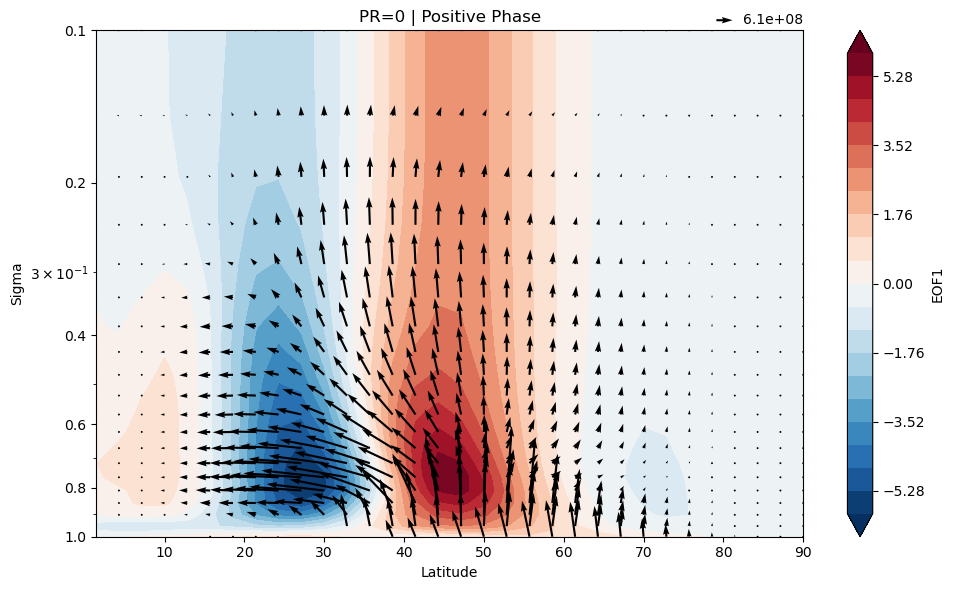

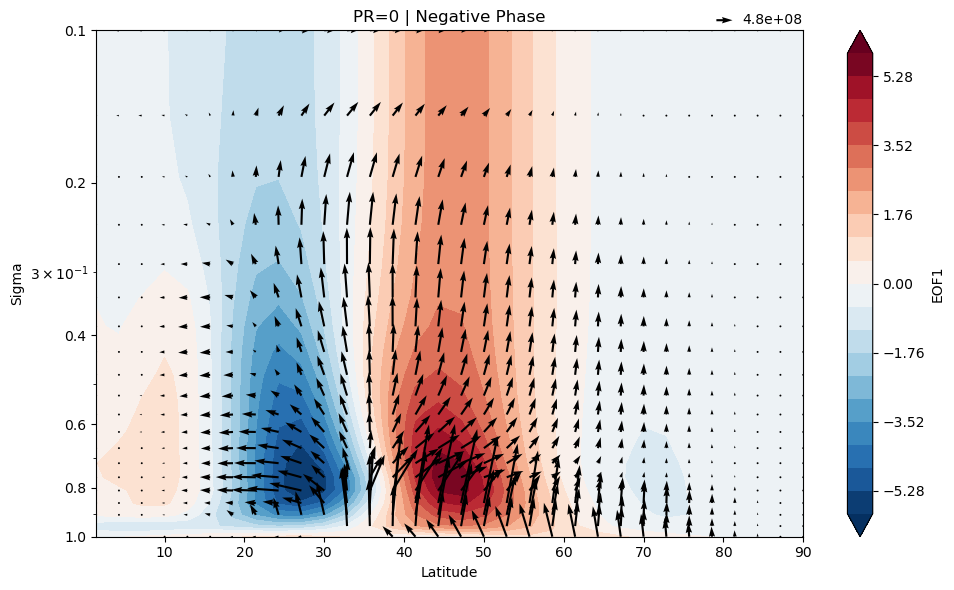

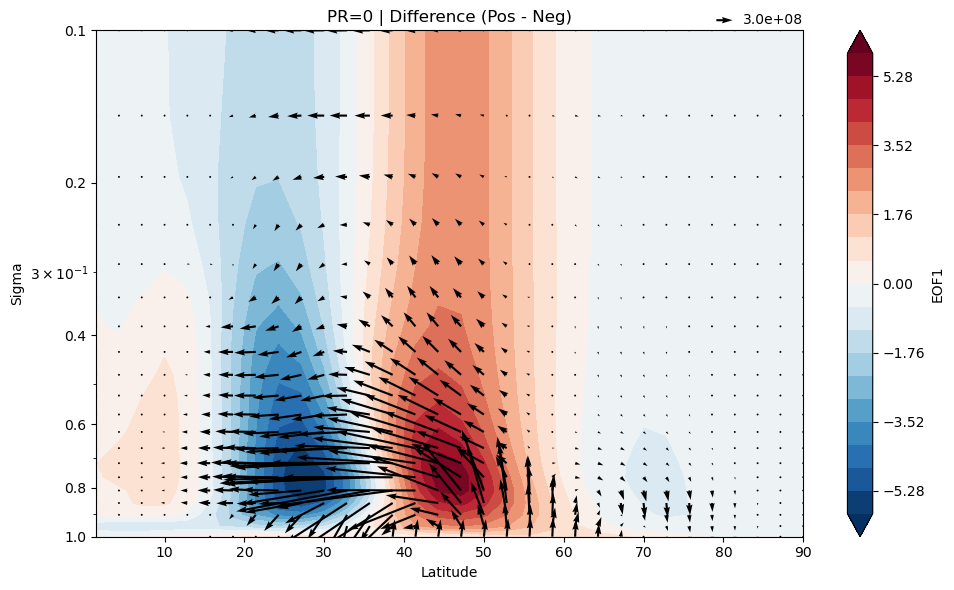


Processing PR = 10 (Index 1)
  [PR=10] Pre-loading 25672 time steps into RAM...
    -> Load complete.
  Computing Positive Phase...
  Computing Negative Phase...
  -> Saved Difference to array index 1 with shape (20, 32)


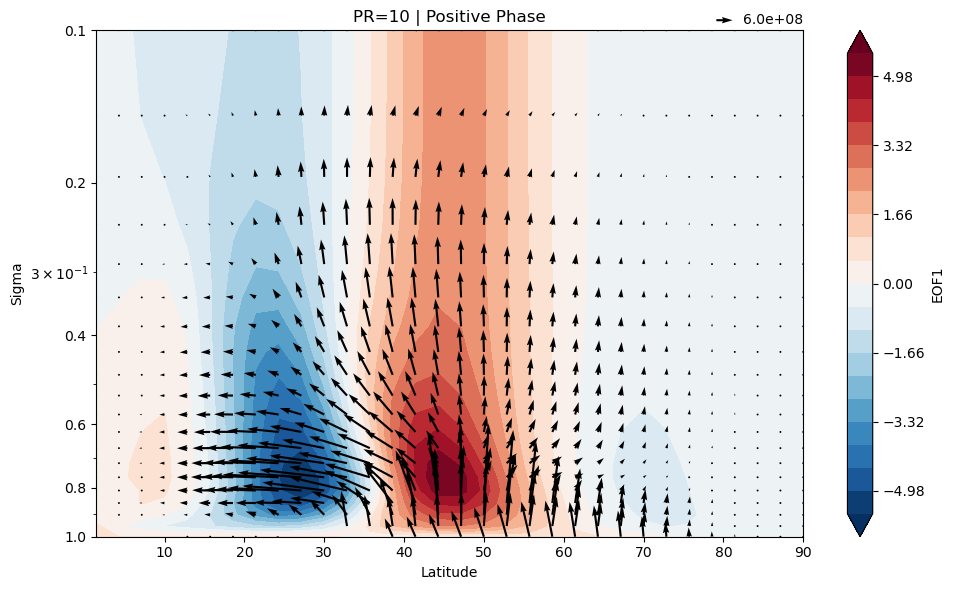

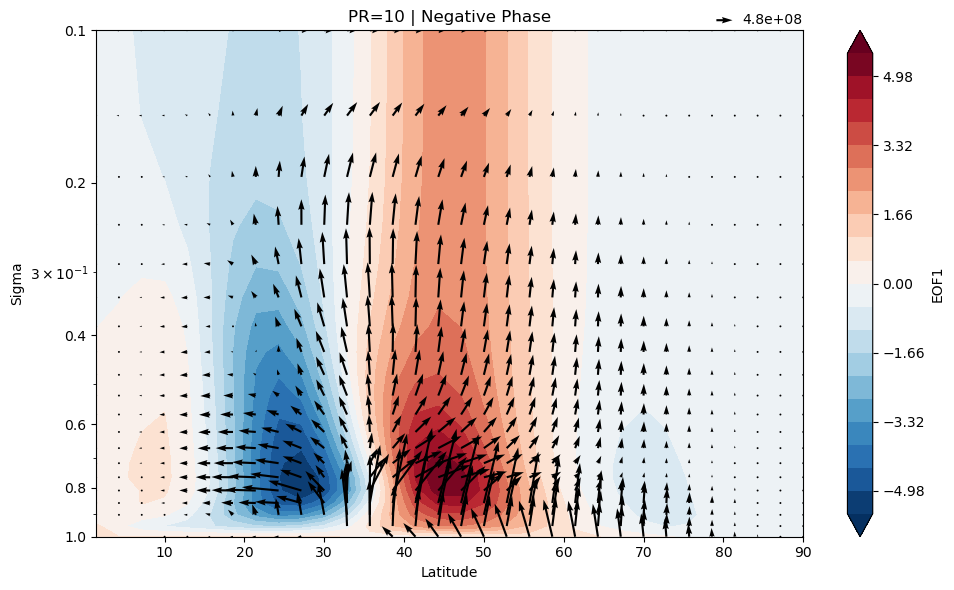

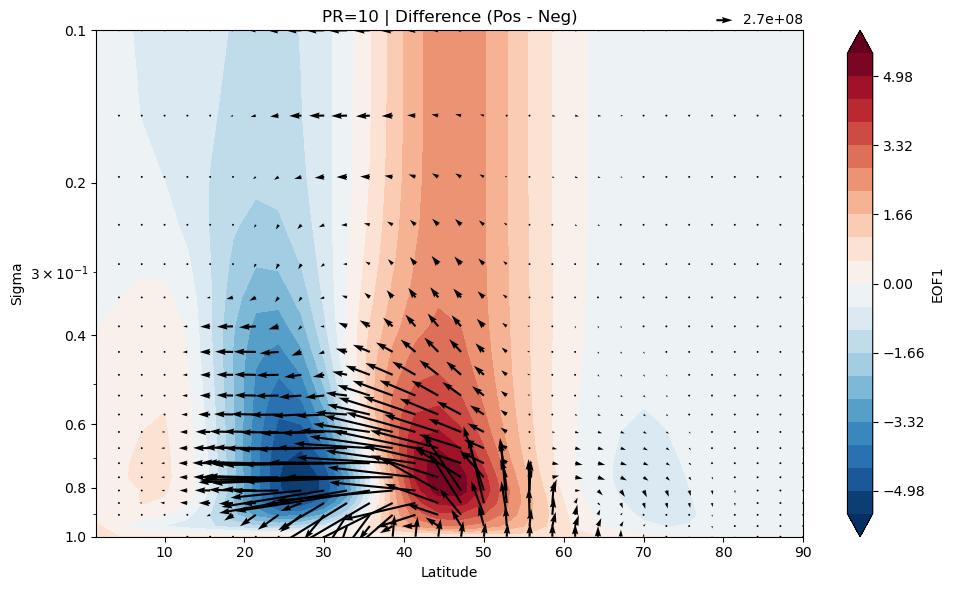


Processing PR = 20 (Index 2)
  [PR=20] Pre-loading 25267 time steps into RAM...
    -> Load complete.
  Computing Positive Phase...
  Computing Negative Phase...
  -> Saved Difference to array index 2 with shape (20, 32)


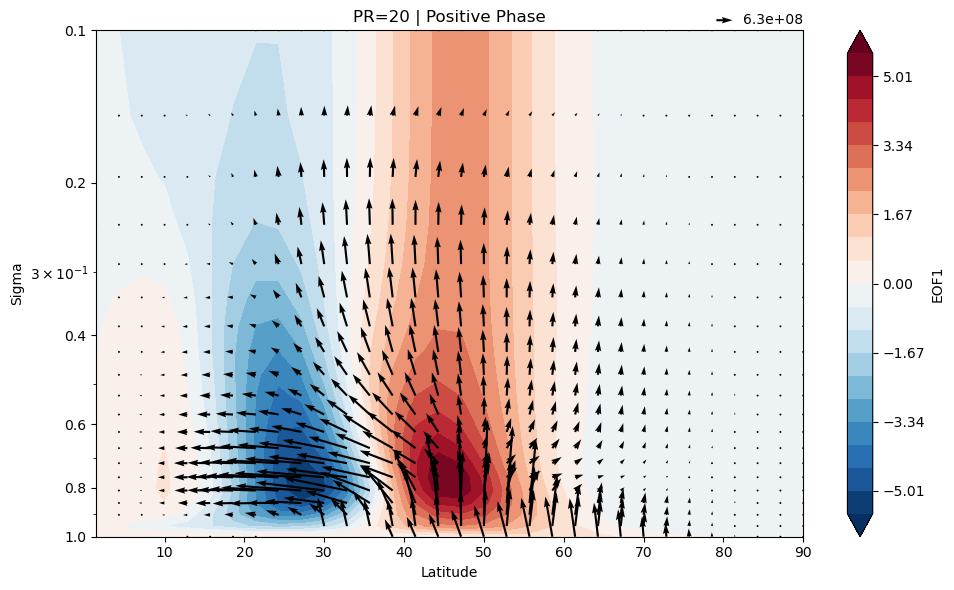

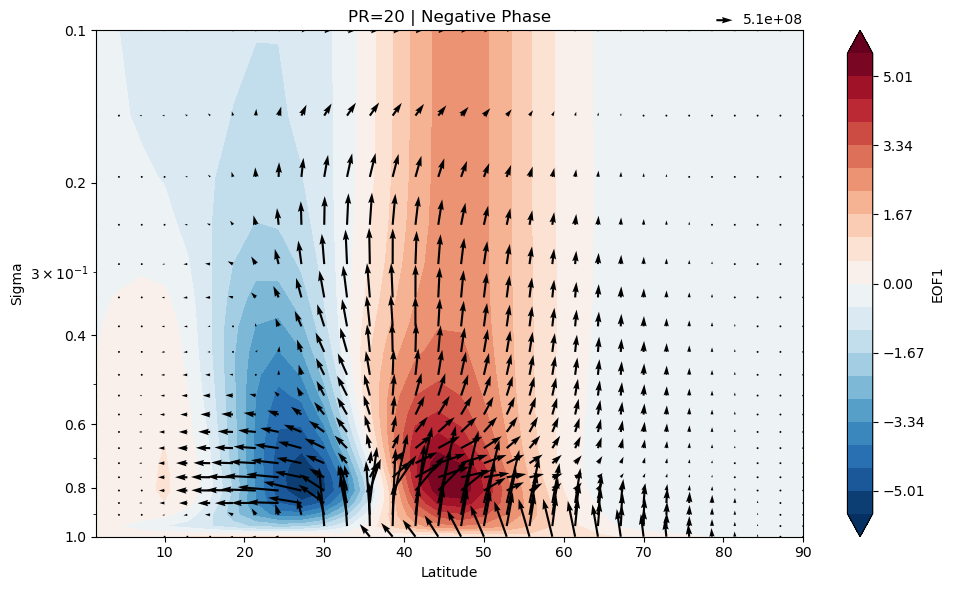

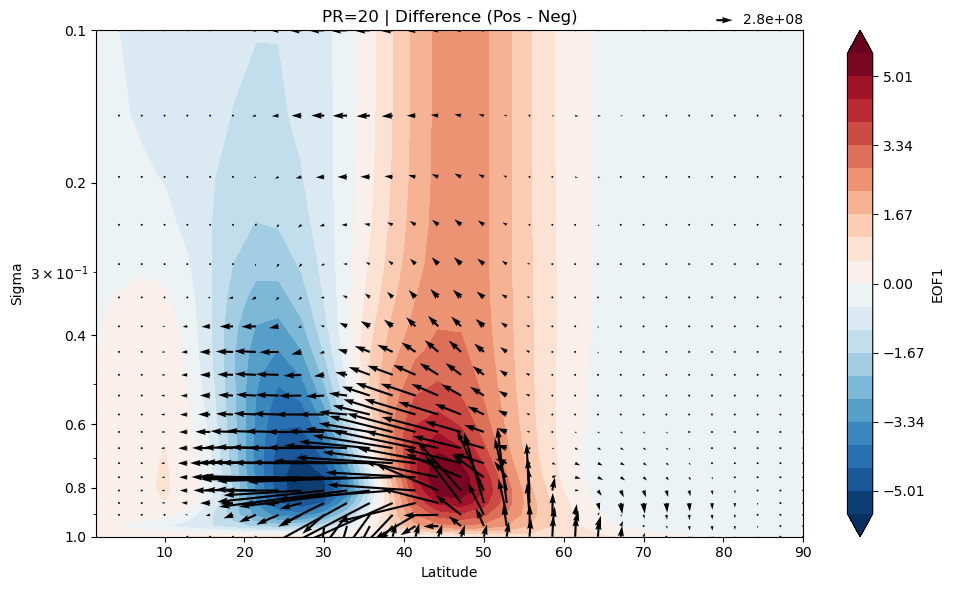


Processing PR = 30 (Index 3)
  [PR=30] Pre-loading 25900 time steps into RAM...
    -> Load complete.
  Computing Positive Phase...
  Computing Negative Phase...
  -> Saved Difference to array index 3 with shape (20, 32)


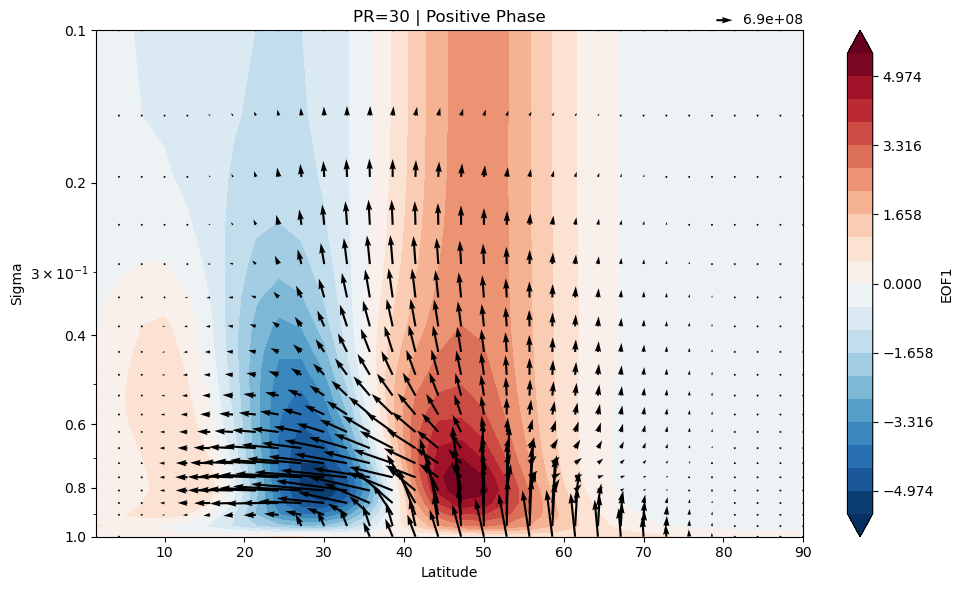

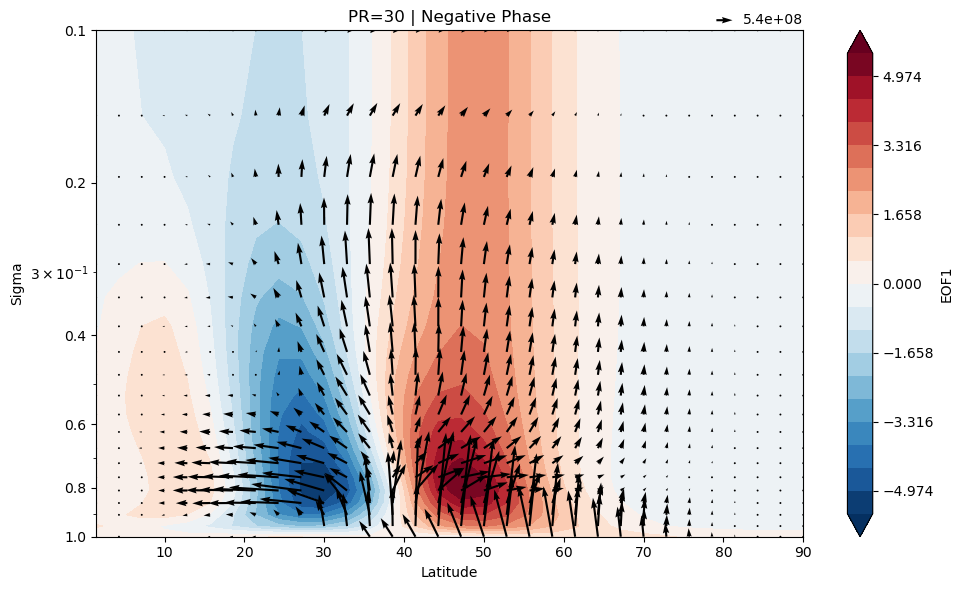

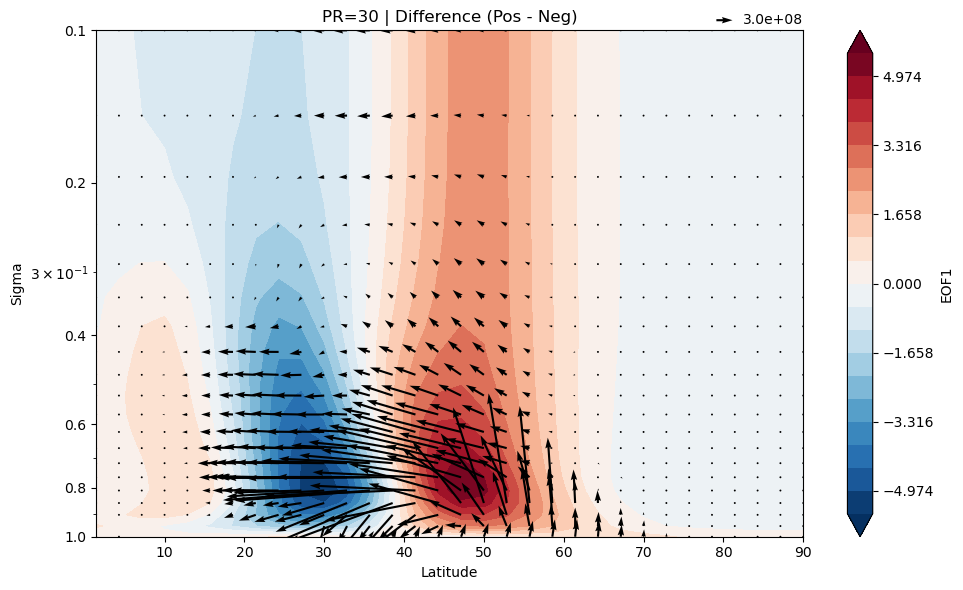


Processing PR = 40 (Index 4)
  [PR=40] Pre-loading 26130 time steps into RAM...
    -> Load complete.
  Computing Positive Phase...
  Computing Negative Phase...
  -> Saved Difference to array index 4 with shape (20, 32)


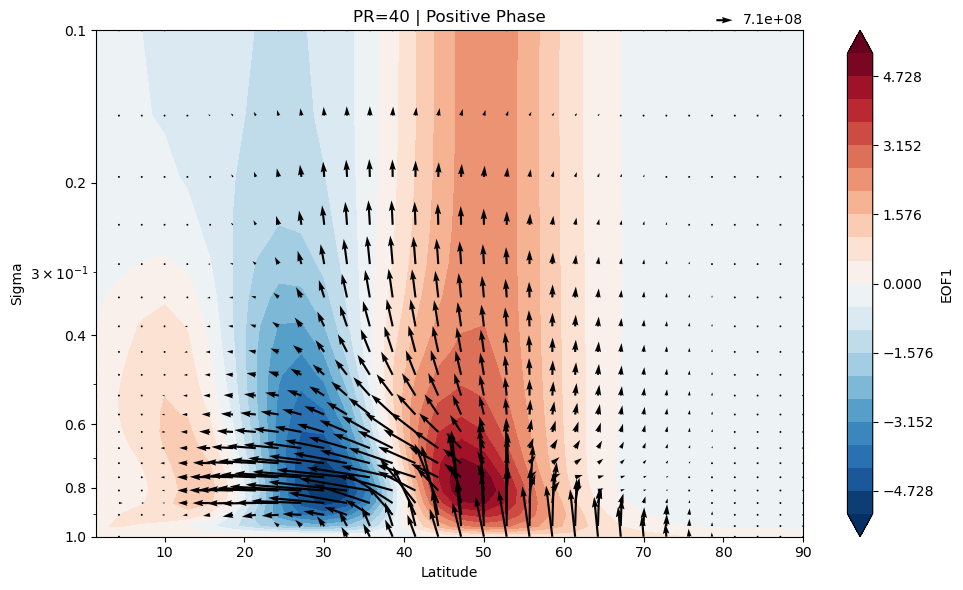

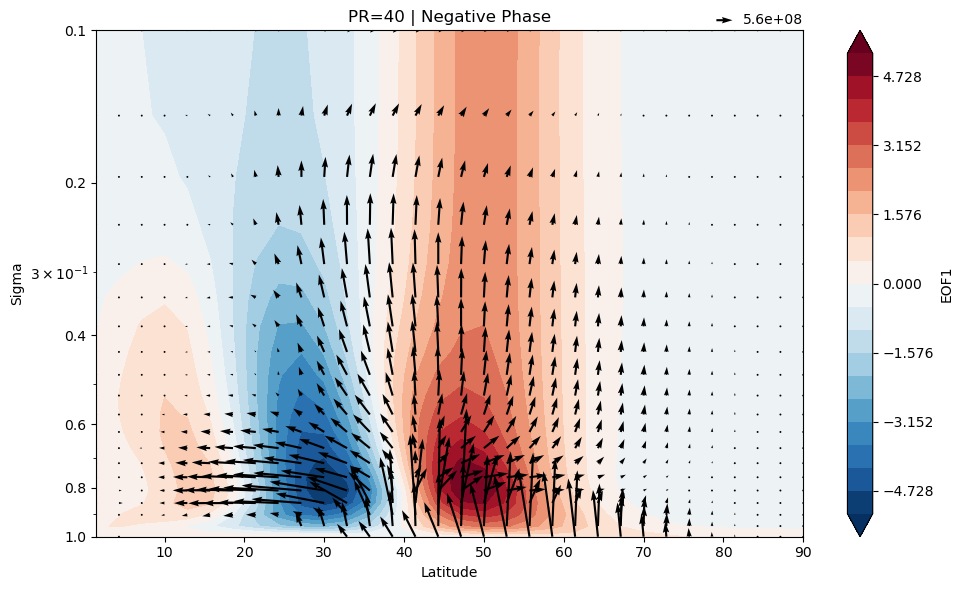

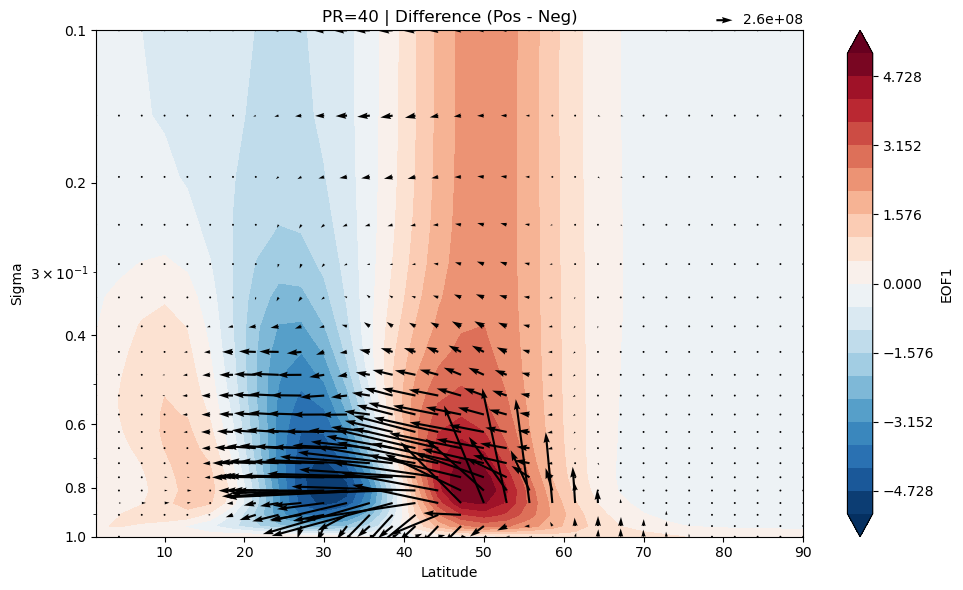


Processing PR = 50 (Index 5)
  [PR=50] Pre-loading 25604 time steps into RAM...
    -> Load complete.
  Computing Positive Phase...
  Computing Negative Phase...
  -> Saved Difference to array index 5 with shape (20, 32)


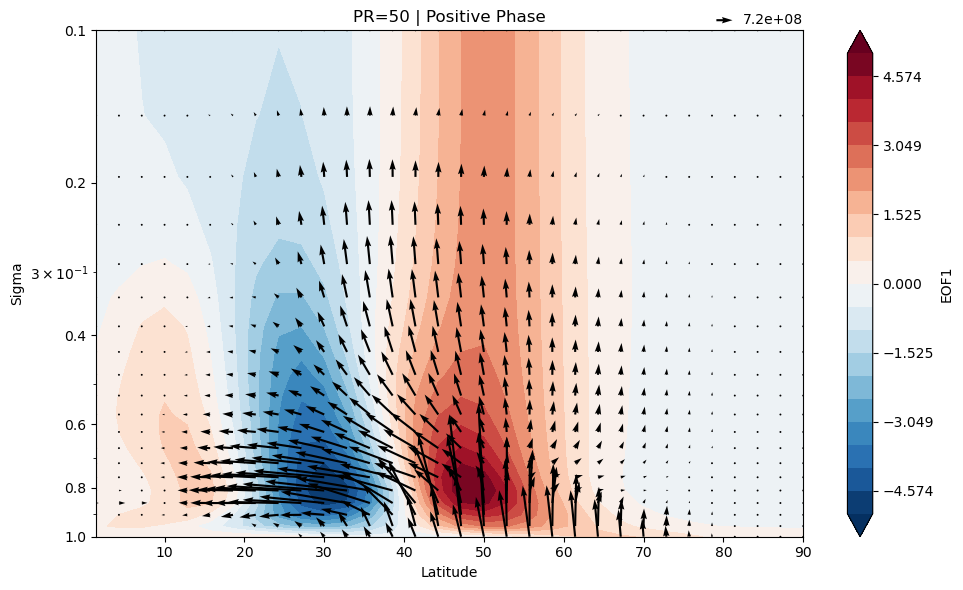

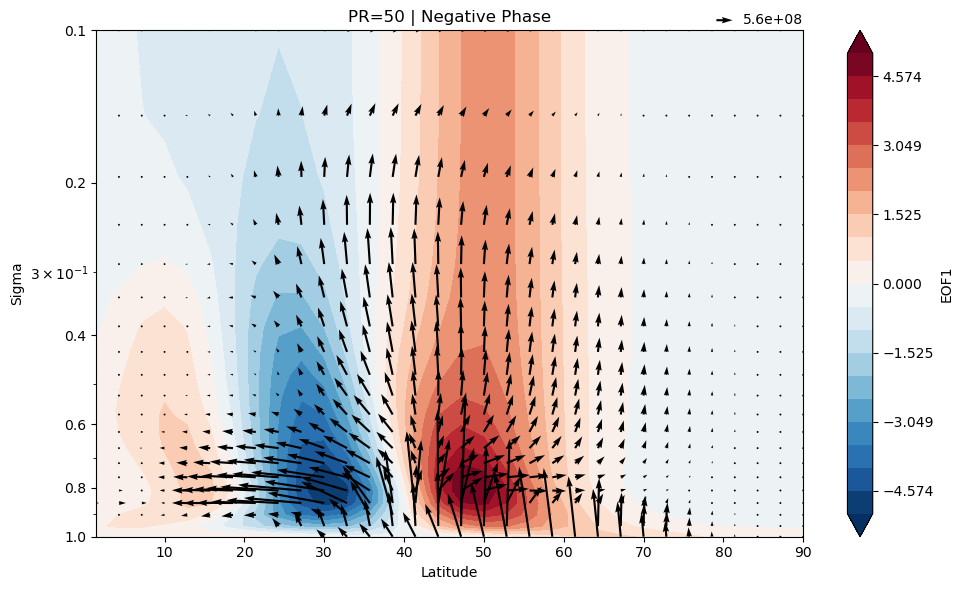

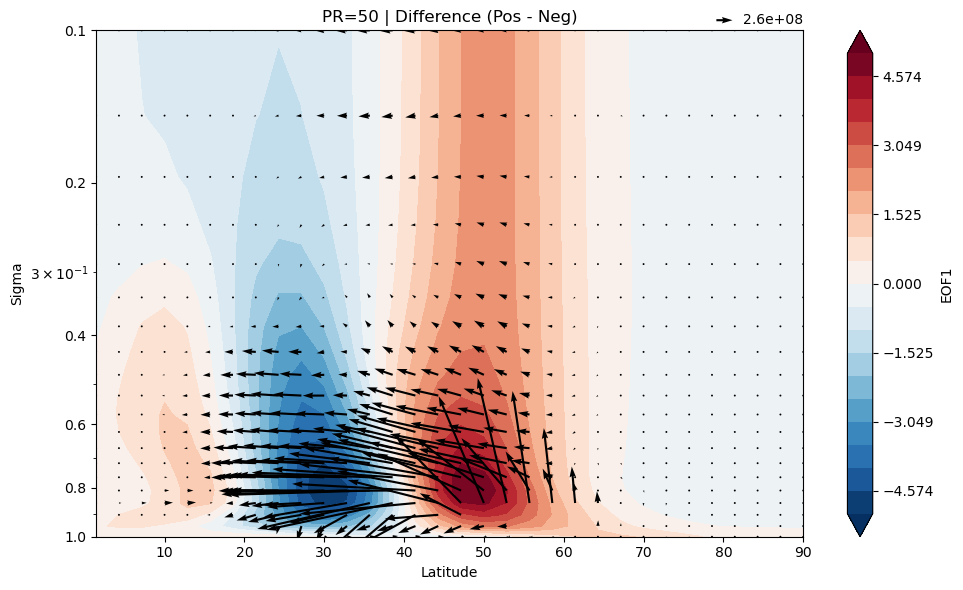


Processing Complete.
Final Variables Created:
saved_Fphi_diff shape: (6, 20, 32)
saved_Fsig_diff shape: (6, 20, 32)


In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# =============================================================================
# CLASS DEFINITION
# =============================================================================

class EPFluxAnalyzer:
    def __init__(self, pr):
        """
        Initialize with Experiment ID (PR).
        Sets up paths and constants. Does NOT load data yet.
        """
        self.pr = pr
        
        # --- Physical Constants ---
        self.a = 6.371e6       # Earth radius (m)
        self.p0 = 100000       # Reference pressure (Pa)
        self.R = 287.0         # Gas constant
        self.cp = 1004.0       # Specific heat
        self.kappa = self.R / self.cp
        
        # --- Grid Definitions ---
        self.lev = np.linspace(1, 0.1, 20)  # Sigma levels
        self.lat_deg = np.linspace(-90, 90, 64)
        
        # --- File Paths ---
        self.base_path = f"/data92/PeterChang/Dycore_data/PR{pr}/"
        self.eof_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PC1_results/EOF1_PR_{pr}.npy"
        
        # --- Memory Cache ---
        self.cache = {}
        self.global_to_local_map = {}

    def pre_load_data(self, all_indices):
        """
        EFFICIENCY OPTIMIZATION:
        Reads ONLY the specified time indices from disk into memory.
        """
        sorted_indices = np.unique(np.sort(all_indices))
        
        print(f"  [PR={self.pr}] Pre-loading {len(sorted_indices)} time steps into RAM...")
        
        self.global_to_local_map = {idx: i for i, idx in enumerate(sorted_indices)}
        
        # Read from disk
        with h5py.File(f"{self.base_path}u/PR{self.pr}_500_20000day_u_6hourly.h5", 'r') as f:
            u_data = f['u'][sorted_indices]
            
        with h5py.File(f"{self.base_path}v/PR{self.pr}_500_20000day_v_6hourly.h5", 'r') as f:
            v_data = f['v'][sorted_indices]
            
        with h5py.File(f"{self.base_path}t/PR{self.pr}_500_20000day_t_6hourly.h5", 'r') as f:
            t_data = f['t'][sorted_indices]
            
        with h5py.File(f"{self.base_path}ps/PR{self.pr}_500_20000day_ps_6hourly.h5", 'r') as f:
            ps_data = f['ps'][sorted_indices]
            if ps_data.ndim == 4:
                ps_data = ps_data[:, 0, :, :]

        self.cache = {'u': u_data, 'v': v_data, 't': t_data, 'ps': ps_data}
        print("    -> Load complete.")

    def _get_subset(self, indices):
        local_idxs = []
        for idx in indices:
            if idx in self.global_to_local_map:
                local_idxs.append(self.global_to_local_map[idx])
        
        if not local_idxs:
            raise ValueError("Indices not found in pre-loaded cache!")
            
        local_idxs = np.array(local_idxs)
        
        return (
            self.cache['u'][local_idxs],
            self.cache['v'][local_idxs],
            self.cache['t'][local_idxs],
            self.cache['ps'][local_idxs]
        )

    def compute_ep_flux(self, indices):
        """
        Calculates EP Flux (F_phi, F_sigma) for the given indices.
        Returns shapes (20, 64).
        """
        u, v, t, ps = self._get_subset(indices)
        
        # Geometry
        lat_rad = np.radians(self.lat_deg)
        cos_phi = np.cos(lat_rad)
        sin_phi = np.sin(lat_rad)
        
        # Calculate Theta
        p = self.lev[None, :, None, None] * ps[:, None, :, :]
        theta = t * (self.p0 / p) ** self.kappa
        
        # Decompose
        u_zonal = np.mean(u, axis=-1)
        theta_zonal = np.mean(theta, axis=-1)
        theta_bar = np.mean(theta_zonal, axis=0) # Time mean
        
        u_prime = u - u_zonal[..., None]
        v_prime = v - np.mean(v, axis=-1)[..., None]
        theta_prime = theta - theta_zonal[..., None]
        
        # Fluxes
        uv_prime = np.mean(u_prime * v_prime, axis=(0, 3))
        vtheta_prime = np.mean(v_prime * theta_prime, axis=(0, 3))
        
        # Vectors
        dtheta_dsigma = np.gradient(theta_bar, self.lev, axis=0)
        dtheta_dsigma[np.abs(dtheta_dsigma) < 50] = np.nan

        F_phi = -self.a * cos_phi[None, :] * uv_prime
        F_sigma = self.a * cos_phi[None, :] * sin_phi[None, :] * vtheta_prime / dtheta_dsigma
        
        return F_phi, F_sigma

    def plot(self, F_phi, F_sigma, title_suffix, scale_factor=1000.0):
        """
        Plots EP flux sliced at [:, 32:] to match EOF1 (20, 32).
        """
        # 1. Load EOF (Expected shape 20, 32)
        if os.path.exists(self.eof_path):
            eof1 = np.load(self.eof_path)
        else:
            print(f"    [Warning] EOF file not found: {self.eof_path}")
            # Fallback size (20, 32)
            eof1 = np.zeros((len(self.lev), 32))

        # 2. Slice Data to match (20, 32)
        # We take the last 32 latitude points (Northern Hemisphere usually)
        lat_sub = self.lat_deg[32:]
        F_phi_sub = F_phi[:, 32:]
        F_sigma_sub = F_sigma[:, 32:]
        
        # Create Meshgrid for the SLICED data
        Lat_sub, Sigma_sub = np.meshgrid(lat_sub, self.lev)
        
        # Check shapes (Debug)
        if eof1.shape != Lat_sub.shape:
            print(f"    [Error] Shape Mismatch! EOF: {eof1.shape}, Grid: {Lat_sub.shape}")
            return

        fig, ax = plt.subplots(figsize=(10, 6))
        
        # 3. Background EOF contours
        vmax = np.nanmax(np.abs(eof1))
        if vmax == 0: vmax = 1
        levels = np.linspace(-vmax, vmax, 21)
        
        cf = ax.contourf(Lat_sub, Sigma_sub, -eof1, cmap="RdBu_r", levels=levels, extend='both')
        cb = fig.colorbar(cf, ax=ax)
        cb.set_label("EOF1")
        
        # 4. Quiver (Vectors)
        msk = ~np.isnan(F_sigma_sub)
        
        # Note: using SLICED arrays here
        Q = ax.quiver(
            Lat_sub[msk], Sigma_sub[msk], 
            F_phi_sub[msk], -F_sigma_sub[msk] * scale_factor,
            angles='uv', scale_units='inches', width=0.003
        )
        
        # Quiver Key
        fig.canvas.draw()
        if Q.scale:
            bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
            width_in = bbox.width
            ref_len = Q.scale / width_in
            ax.quiverkey(Q, 0.9, 1.02, ref_len, label=f'{Q.scale:.1e}', labelpos='E', coordinates='axes')

        # 5. Formatting
        ax.set_ylim(1, 0.1)
        ax.set_yscale("log")
        ax.set_yticks([1, 0.8, 0.6, 0.4, 0.2, 0.1])
        ax.get_yaxis().set_major_formatter(mticker.ScalarFormatter())
        
        # Limits based on the sliced latitude (approx 0 to 90)
        ax.set_xlim(lat_sub.min(), lat_sub.max()) 
        
        ax.set_xlabel("Latitude")
        ax.set_ylabel("Sigma")
        ax.set_title(f"PR={self.pr} | {title_suffix}")
        
        plt.tight_layout()
        plt.show()

# =============================================================================
# MAIN EXECUTION LOOP
# =============================================================================

if __name__ == "__main__":
    
    # 1. Setup Experiments and Storage
    PR_list = [0, 10, 20, 30, 40, 50]  # Exact 6 experiments
    idx_base = "/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx"
    
    # Initialize Storage Arrays: Shape (6, 20, 32)
    # 6 Experiments, 20 Levels, 32 Latitudes (Northern Hemisphere)
    saved_Fphi_diff = np.zeros((len(PR_list), 20, 32))
    saved_Fsig_diff = np.zeros((len(PR_list), 20, 32))

    # 2. Main Loop
    for i, pr in enumerate(PR_list):
        print(f"\n{'='*40}")
        print(f"Processing PR = {pr} (Index {i})")
        print(f"{'='*40}")
        
        # Initialize
        analyzer = EPFluxAnalyzer(pr)
        
        # Get Indices
        try:
            with h5py.File(f"{idx_base}/PC1_positive_1std_PR{pr}.h5", 'r') as f:
                pos_idx = f['time_idx_pos'][0]
            with h5py.File(f"{idx_base}/PC1_negative_1std_PR{pr}.h5", 'r') as f:
                neg_idx = f['time_idx_neg'][0]
        except FileNotFoundError:
            print(f"  [Error] Index files missing for PR{pr}. Skipping...")
            continue
            
        # Pre-load Data
        needed_indices = np.unique(np.concatenate([pos_idx, neg_idx]))
        analyzer.pre_load_data(needed_indices)
        
        # Compute Fluxes (Global Shape: 20, 64)
        print("  Computing Positive Phase...")
        Fphi_pos, Fsig_pos = analyzer.compute_ep_flux(pos_idx)
        
        print("  Computing Negative Phase...")
        Fphi_neg, Fsig_neg = analyzer.compute_ep_flux(neg_idx)
        
        # ---------------------------------------------------------
        # SAVE DIFFERENCE TO STORAGE
        # ---------------------------------------------------------
        # Calculate Difference (Global)
        diff_phi_global = Fphi_pos - Fphi_neg
        diff_sig_global = Fsig_pos - Fsig_neg
        
        # Slice for Northern Hemisphere [:, 32:] and store in index i
        saved_Fphi_diff[i] = diff_phi_global[:, 32:]
        saved_Fsig_diff[i] = diff_sig_global[:, 32:]
        
        print(f"  -> Saved Difference to array index {i} with shape {saved_Fphi_diff[i].shape}")

        # ---------------------------------------------------------
        # PLOTTING
        # ---------------------------------------------------------
        analyzer.plot(Fphi_pos, Fsig_pos, "Positive Phase")
        analyzer.plot(Fphi_neg, Fsig_neg, "Negative Phase")
        analyzer.plot(diff_phi_global, diff_sig_global, "Difference (Pos - Neg)")
        
        del analyzer

    # 3. Final Check (Optional: Save to disk)
    print("\nProcessing Complete.")
    print("Final Variables Created:")
    print("saved_Fphi_diff shape:", saved_Fphi_diff.shape)
    print("saved_Fsig_diff shape:", saved_Fsig_diff.shape)
    
    # If you want to save them to a file:
    # np.save("EP_Flux_Diff_Phi.npy", saved_Fphi_diff)
    # np.save("EP_Flux_Diff_Sig.npy", saved_Fsig_diff)

# plot EP flux the difference from each exp and L = Dry

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

def plot_saved_result(pr, F_phi, F_sigma, title, scale_factor=1000.0):
    """
    Plots the ALREADY SLICED (20, 32) EP flux data.
    """
    quivArgs = {'angles':'uv','scale_units':'inches', 'width':3.5e-3}
    
    # 1. Re-define Grid (Since analyzer is gone)
    lev = np.linspace(1, 0.1, 20)
    lat_deg = np.linspace(-90, 90, 64)
    lat_sub = lat_deg[32:]  # The +90 to 0 (Northern Hemisphere) subset
    
    # 2. Load the correct EOF for this PR
    eof_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PC1_results/EOF1_PR_{pr}.npy"
    
    if os.path.exists(eof_path):
        eof1 = np.load(eof_path) # Shape (20, 32)
    else:
        print(f"[Warning] EOF file not found for PR{pr}. Using zeros.")
        eof1 = np.zeros((20, 32))

    # 3. Plot Setup
    fig, ax = plt.subplots(figsize=(10, 6))
    Lat_sub, Sigma_sub = np.meshgrid(lat_sub, lev)

    # 4. Background EOF contours
    vmax = np.nanmax(np.abs(eof1))
    if vmax == 0: vmax = 1
    levels = np.linspace(-vmax, vmax, 21)
    
    cf = ax.contourf(Lat_sub, Sigma_sub, -eof1, cmap="RdBu_r", levels=levels, extend='both')
    cb = fig.colorbar(cf, ax=ax)
    cb.set_label("EOF1")

    # 5. Quiver (Vectors)
    msk = ~np.isnan(F_sigma)
    
    # We plot directly (no extra slicing needed)
    Q = ax.quiver(
        Lat_sub[msk], Sigma_sub[msk], 
        F_phi[msk], -F_sigma[msk] * scale_factor,
        # angles='uv', scale_units='inches', width=0.003
        **quivArgs
    )

    # Quiver Key
    fig.canvas.draw()
    if Q.scale:
        bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        width_in = bbox.width
        ref_len = Q.scale / width_in
        ax.quiverkey(Q, 0.9, 1.02, ref_len, label=f'{Q.scale:.1e}', labelpos='E', coordinates='axes')

    # 6. Formatting
    ax.set_ylim(1, 0.1)
    ax.set_yscale("log")
    ax.set_yticks([1, 0.8, 0.6, 0.4, 0.2, 0.1])
    ax.get_yaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlim(lat_sub.min(), lat_sub.max()) 
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Sigma")
    ax.set_title(f"PR={pr} | {title}")
    
    plt.tight_layout()
    plt.show()

Plotting Double Diff: (PR10 Anomaly) - (PR0 Anomaly)...


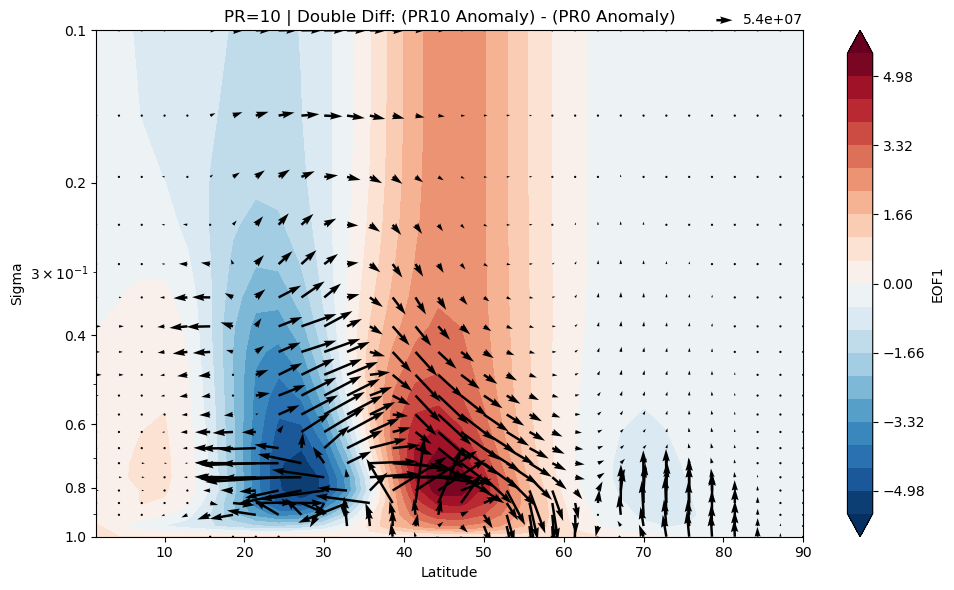

Plotting Double Diff: (PR20 Anomaly) - (PR0 Anomaly)...


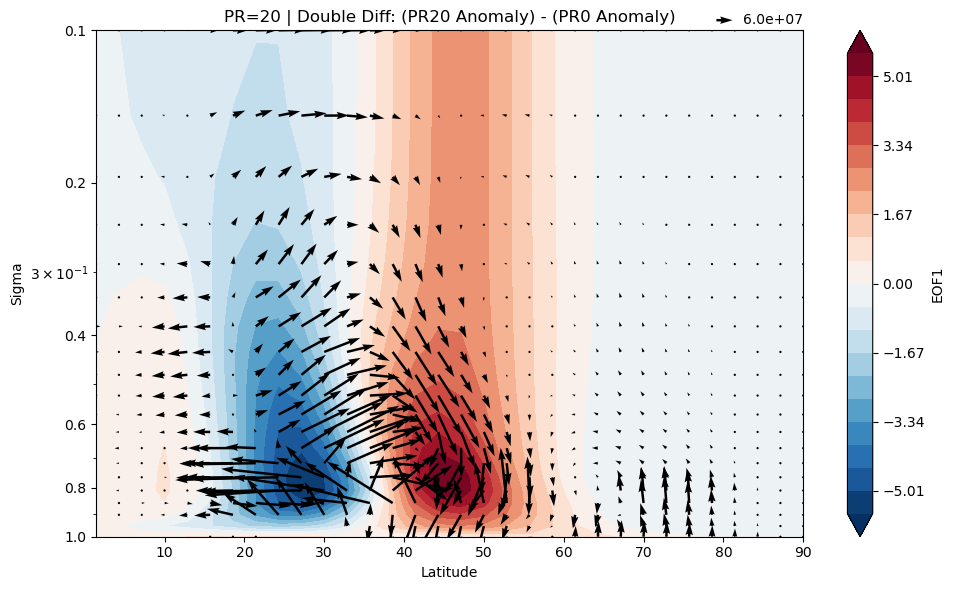

Plotting Double Diff: (PR30 Anomaly) - (PR0 Anomaly)...


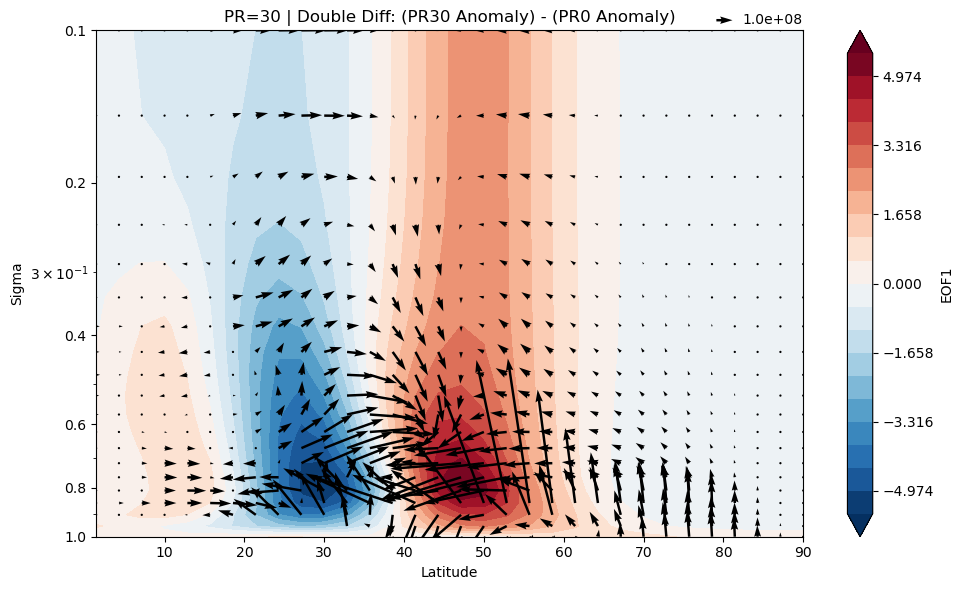

Plotting Double Diff: (PR40 Anomaly) - (PR0 Anomaly)...


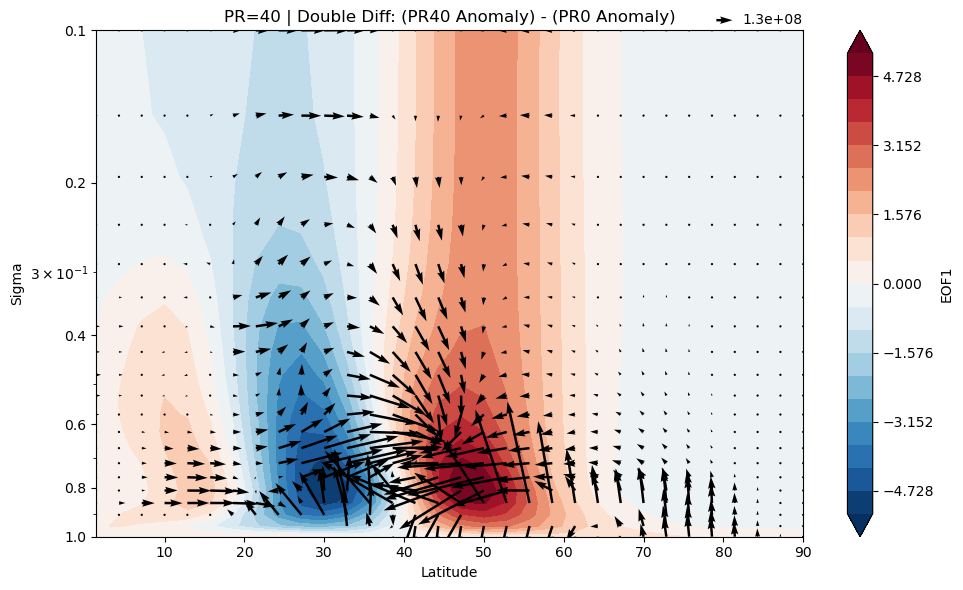

Plotting Double Diff: (PR50 Anomaly) - (PR0 Anomaly)...


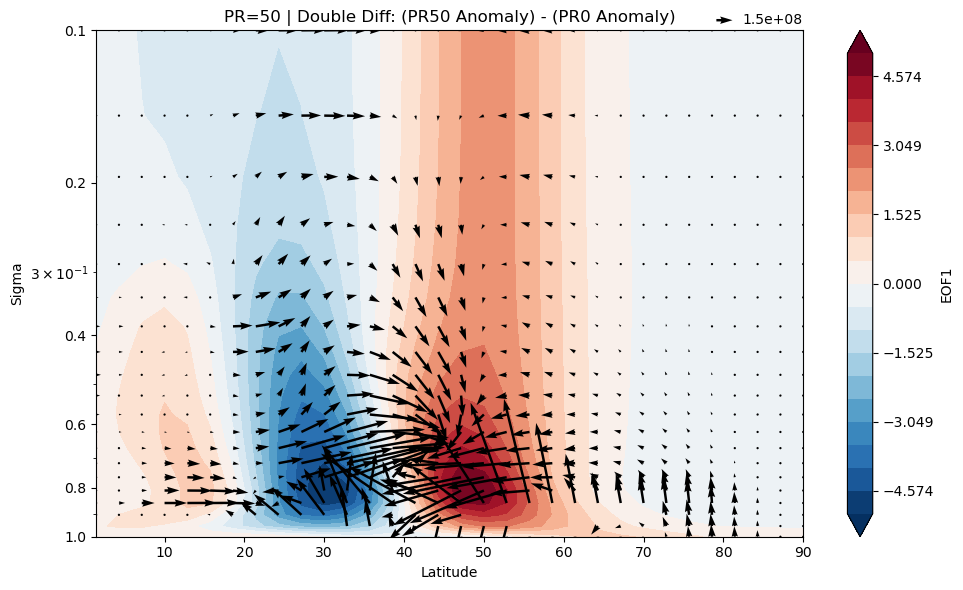

In [27]:
# List of experiments corresponding to indices 0, 1, 2, 3, 4, 5
PR_list = [0, 10, 20, 30, 40, 50]

# We start from index 1 (PR=10) because index 0 is the baseline
for i in range(1, len(PR_list)):
    pr_current = PR_list[i]
    
    # 1. Calculate the Double Difference
    # (Current Exp Difference) - (PR0 Difference)
    diff_phi_vs_dry = saved_Fphi_diff[i] - saved_Fphi_diff[0]
    diff_sig_vs_dry = saved_Fsig_diff[i] - saved_Fsig_diff[0]
    
    # 2. Create a descriptive title
    # e.g., "PR=50 (Pos-Neg) minus PR=0 (Pos-Neg)"
    title_text = f"Double Diff: (PR{pr_current} Anomaly) - (PR0 Anomaly)"
    
    # 3. Plot
    # We pass 'pr_current' so the background EOF corresponds to the current experiment
    print(f"Plotting {title_text}...")
    plot_saved_result(
        pr_current, 
        diff_phi_vs_dry, 
        diff_sig_vs_dry, 
        title_text,
        scale_factor=1000.0  # Adjust arrow scale if needed
    )

## Saving the EP flux difference from L = Dry 

In [28]:
print(saved_Fphi_diff.shape)
print(saved_Fsig_diff.shape)


(6, 20, 32)
(6, 20, 32)


In [29]:
np.save("EP_Flux_Fphi_diff.npy", saved_Fphi_diff)
np.save("EP_Flux_Fsig_diff.npy", saved_Fsig_diff)